<a href="https://colab.research.google.com/github/RenzoEspinozaTuesta/Miner-a-de-Datos/blob/main/BDA_Gesti%C3%B3n_de_no_clientes_con_oferta_de_tarjeta_de_cr%C3%A9dito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Elaborado por:
- Renzo Espinoza Tuesta
- Anthony Henry Arias Zevallos

# **Tarea 5 - Teoría - Big Data Analytics**
---
---

# **1. IDENTIFICACIÓN DEL PROBLEMA-MAPA DEL PROCESO**
---

# **1.1. IDENTIFICACIÓN DEL PROBLEMA**
---

Descripción

El reto consiste en desarrollar un algoritmo predictivo que maximice la ganancia total generada por la gestión de no clientes con oferta de tarjeta de crédito. Estos clientes nuevos han sido contactados por Interbank por la web o telefónicamente. El objetivo del reto es que los participantes indiquen en su ouput a quiénes deberíamos ofrecerle una tarjeta de crédito, teniendo en cuenta que lo que se desea obtener es el margen máximo posible.

Además de forma general, la ganancia para un cliente que adquiere una tarjeta de crédito es un indicador relacionado a sus transacciones a lo largo de determinado periodo, mientras que la ganancia de un cliente que no adquiere una tarjeta de crédito solo incluye los costos de gestionar su oferta (pérdida). Todo esto ya esta construido en el campo 'margen' de la base inicial.

Base de entrenamiento

La base de entrenamiento contiene información ofuscada histórica sobre los no clientes con oferta de TC que dejaron sus datos en la página web de Interbank o fueron contactados telefónicamente. Se incluyen variables sobre la navegación en la página web, sociodemográficas, variables sobre la oferta de campaña de tarjetas de crédito, variables del sistema financiero, variables sobre tributos(SUNAT) y de posesión de vehiculos.

# **1.1. MAPA DEL PROCESO**
---

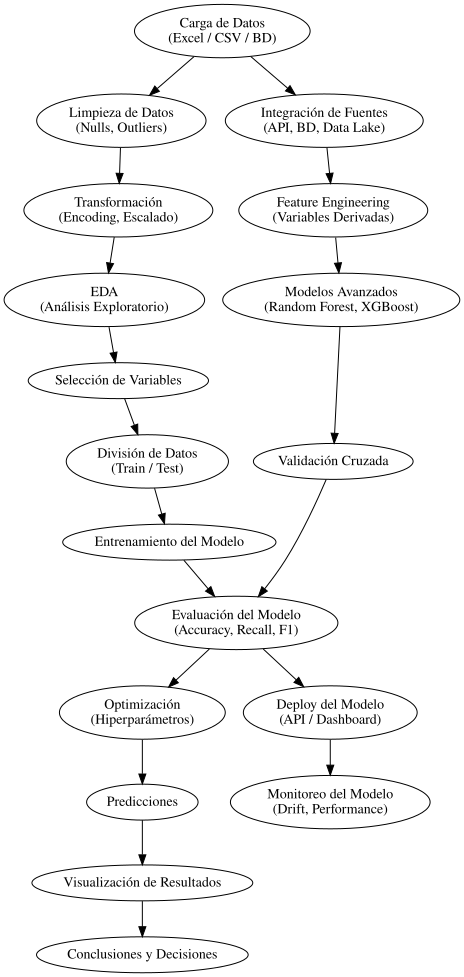

In [ ]:
# Instalar graphviz si es necesario
!pip install graphviz

from graphviz import Digraph

# Crear el diagrama
dot = Digraph(format='png')

# =========================
# PROCESO GENERAL DEL NOTEBOOK
# =========================

dot.node('A', 'Carga de Datos\n(Excel / CSV / BD)')
dot.node('B', 'Limpieza de Datos\n(Nulls, Outliers)')
dot.node('C', 'Transformación\n(Encoding, Escalado)')
dot.node('D', 'EDA\n(Análisis Exploratorio)')
dot.node('E', 'Selección de Variables')
dot.node('F', 'División de Datos\n(Train / Test)')
dot.node('G', 'Entrenamiento del Modelo')
dot.node('H', 'Evaluación del Modelo\n(Accuracy, Recall, F1)')
dot.node('I', 'Optimización\n(Hiperparámetros)')
dot.node('J', 'Predicciones')
dot.node('K', 'Visualización de Resultados')
dot.node('L', 'Conclusiones y Decisiones')

# Flujo principal
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'H')
dot.edge('H', 'I')
dot.edge('I', 'J')
dot.edge('J', 'K')
dot.edge('K', 'L')

# =========================
# PROCESO MEJORADO CON IA / ML AVANZADO
# =========================

dot.node('M', 'Integración de Fuentes\n(API, BD, Data Lake)')
dot.node('N', 'Feature Engineering\n(Variables Derivadas)')
dot.node('O', 'Modelos Avanzados\n(Random Forest, XGBoost)')
dot.node('P', 'Validación Cruzada')
dot.node('Q', 'Deploy del Modelo\n(API / Dashboard)')
dot.node('R', 'Monitoreo del Modelo\n(Drift, Performance)')

# Flujo mejorado
dot.edge('A', 'M')
dot.edge('M', 'N')
dot.edge('N', 'O')
dot.edge('O', 'P')
dot.edge('P', 'H')
dot.edge('H', 'Q')
dot.edge('Q', 'R')

# Mostrar diagrama
dot

# **2. LOADING DATA FROM GOOGLE DRIVE**
---

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


- Importa el módulo drive de Colab
- Este módulo permite conectar tu entorno de Python con tu Google Drive.
- "Montar” significa conectar tu Google Drive al entorno de Colab
- /content/drive es la carpeta donde se verá tu Drive dentro de Colab

## **2.1. CARGA Y EXPLORACIÓN INICIAL DE DATOS.**
---

In [ ]:
import zipfile
import pandas as pd
import os

# Define the base path to your Google Drive
drive_base_path = '/content/drive/MyDrive/' # For a personal Drive, it's typically 'MyDrive'

# Define the specific folder and zip file name
drive_folder_name = 'BIG_DATA_ANALYTICS'
zip_file_name_gd = 'tarea_ib_base_campanias.zip'

# Construct the full path to the zip file in Google Drive
zip_file_full_path_gd = os.path.join(drive_base_path, drive_folder_name, zip_file_name_gd)

# Define an extraction path within Colab's temporary storage
extraction_path_gd = './extracted_campanias_from_drive/'
os.makedirs(extraction_path_gd, exist_ok=True)

print(f"Attempting to extract: {zip_file_full_path_gd}")
print(f"To extraction path: {extraction_path_gd}")

try:
    # Unzip the file
    with zipfile.ZipFile(zip_file_full_path_gd, 'r') as zip_ref:
        zip_ref.extractall(extraction_path_gd)
    print(f"Successfully extracted '{zip_file_name_gd}' to '{extraction_path_gd}'.")

    # List the contents of the extracted directory
    extracted_files_gd = os.listdir(extraction_path_gd)
    print("Contents of the extracted directory:")
    for f in extracted_files_gd:
        print(f)

    # Dictionary to hold all loaded DataFrames
    dataframes = {}
    for file in extracted_files_gd:
        if file.endswith('.csv'):
            file_path_gd = os.path.join(extraction_path_gd, file)
            df_name = file.replace('.csv', '') # Use filename as key
            dataframes[df_name] = pd.read_csv(file_path_gd)
            print(f"Loaded {file} into dataframes['{df_name}'].")
            display(dataframes[df_name].head())

    # You can now access individual DataFrames like: dataframes['ib_base_campanias']
    # For backward compatibility, if 'ib_base_campanias' was specifically needed:
    if 'ib_base_campanias' in dataframes:
        df_campaigns_gd = dataframes['ib_base_campanias']
        print("df_campaigns_gd is also set to dataframes['ib_base_campanias'] for previous references.")

except FileNotFoundError:
    print(f"Error: Zip file not found at {zip_file_full_path_gd}. Please ensure the path and filename are correct and Google Drive is mounted.")
except Exception as e:
    print(f"An error occurred during extraction or loading: {e}")

Attempting to extract: /content/drive/MyDrive/BIG_DATA_ANALYTICS/tarea_ib_base_campanias.zip
To extraction path: ./extracted_campanias_from_drive/
Successfully extracted 'tarea_ib_base_campanias.zip' to './extracted_campanias_from_drive/'.
Contents of the extracted directory:
ib_base_campanias.csv
ib_base_sunat.csv
ib_base_vehicular.csv
ib_base_reniec.csv
ib_base_digital.csv
ib_base_inicial_train.csv
ib_base_rcc.csv
Loaded ib_base_campanias.csv into dataframes['ib_base_campanias'].


,codmes,id_persona,producto,canal_asignado
0,201801,213598,Adelanto de Sueldo,RED DE TIENDAS
1,201801,237325,Adelanto de Sueldo,RED DE TIENDAS
2,201801,82808,Adquisición Convenios,FFVV
3,201801,90555,Adquisición Convenios,FFVV
4,201801,93408,Adquisición Convenios,FFVV


Loaded ib_base_sunat.csv into dataframes['ib_base_sunat'].


,id_persona,activ_econo,meses_alta
0,174454,Grupo_11,70
1,245154,Grupo_15,27
2,1211,Grupo_07,20
3,146154,Grupo_15,135
4,87697,Grupo_07,55


Loaded ib_base_vehicular.csv into dataframes['ib_base_vehicular'].


...

Loaded ib_base_inicial_train.csv into dataframes['ib_base_inicial_train'].


,codmes,id_persona,codtarget,margen,cem,ingreso_neto,linea_ofrecida
0,201901,165747,0,-5.00,1.0,1781.0,1700
1,201903,100117,0,-5.00,478.0,2106.0,2100
2,201901,65751,1,342.99,687.0,3083.0,4600
3,201901,58047,0,-5.00,182.0,1814.0,3600
4,201901,113221,0,-5.00,582.0,2153.0,4300


Loaded ib_base_rcc.csv into dataframes['ib_base_rcc'].


,codmes,id_persona,cod_banco,producto,clasif,mto_saldo,rango_mora
0,201811,10155,29,PRESTAMOS COMERCIALES,0.0,36698.4870,1.0
1,201804,75442,29,PRESTAMO PERSONAL,0.0,7971.1182,1.0
2,201902,172772,29,PRESTAMOS COMERCIALES,0.0,821.6077,1.0
3,201810,187572,29,PRESTAMOS COMERCIALES,0.0,9271.8030,1.0
4,201903,255598,29,PRESTAMOS COMERCIALES,0.0,10548.7263,1.0


df_campaigns_gd is also set to dataframes['ib_base_campanias'] for previous references.


zipfile = para descomprimir archivos .zip

pandas = para trabajar con DataFrames

os = para manejar rutas y archivos

---
Aquí defines dónde está tu Drive:

- drive_base_path = '/content/drive/MyDrive/'

- drive_folder_name = 'BIG_DATA_ANALYTICS'

- zip_file_name_gd = 'tarea_ib_base_campanias.zip'

---

zip_file_full_path_gd = os.path.join(drive_base_path, drive_folder_name, zip_file_name_gd)

Une todo en una sola ruta: /content/drive/MyDrive/BIG_DATA_ANALYTICS/tarea_ib_base_campanias.zip

---
Crear carpeta de extracción

extraction_path_gd = './extracted_campanias_from_drive/'
os.makedirs(extraction_path_gd, exist_ok=True)

- Crea una carpeta en Colab donde se descomprimirá el zip

- exist_ok=True = evita error si ya existe

---

dataframes = {}
for file in extracted_files_gd:
    if file.endswith('.csv'):

- Recorre cada archivo

- Solo procesa los .csv

---

Guarda cada archivo como un DataFrame dentro de un diccionario:

dataframes[df_name] = pd.read_csv(file_path_gd)

dataframes['ib_base_rcc']
dataframes['ib_base_digital']

---

Mostrar vista previa de primeras filas de cada dataset

display(dataframes[df_name].head())

---

Crea una variable adicional para usar ese DataFrame fácilmente

if 'ib_base_campanias' in dataframes:
    df_campaigns_gd = dataframes['ib_base_campanias']

## **2.2. CONVERTIR 7 SCV QUE CONFORMAN EL DATASET "tarea_ib_base_campanias.zip".**
---

In [ ]:
print("Displaying the head of each requested DataFrame:")

# ib_base_rcc.csv
if 'ib_base_rcc' in dataframes:
    print("\nDataFrame: ib_base_rcc")
    display(dataframes['ib_base_rcc'].head())

# ib_base_vehicular.csv
if 'ib_base_vehicular' in dataframes:
    print("\nDataFrame: ib_base_vehicular")
    display(dataframes['ib_base_vehicular'].head())

# ib_base_campanias.csv
if 'ib_base_campanias' in dataframes:
    print("\nDataFrame: ib_base_campanias")
    display(dataframes['ib_base_campanias'].head())

# ib_base_digital.csv
if 'ib_base_digital' in dataframes:
    print("\nDataFrame: ib_base_digital")
    display(dataframes['ib_base_digital'].head())

# ib_base_inicial_train.csv
if 'ib_base_inicial_train' in dataframes:
    print("\nDataFrame: ib_base_inicial_train")
    display(dataframes['ib_base_inicial_train'].head())

# ib_base_sunat.csv
if 'ib_base_sunat' in dataframes:
    print("\nDataFrame: ib_base_sunat")
    display(dataframes['ib_base_sunat'].head())

# ib_base_reniec.csv
if 'ib_base_reniec' in dataframes:
    print("\nDataFrame: ib_base_reniec")
    display(dataframes['ib_base_reniec'].head())

Displaying the head of each requested DataFrame:

DataFrame: ib_base_rcc


,codmes,id_persona,cod_banco,producto,clasif,mto_saldo,rango_mora
0,201811,10155,29,PRESTAMOS COMERCIALES,0.0,36698.4870,1.0
1,201804,75442,29,PRESTAMO PERSONAL,0.0,7971.1182,1.0
2,201902,172772,29,PRESTAMOS COMERCIALES,0.0,821.6077,1.0
3,201810,187572,29,PRESTAMOS COMERCIALES,0.0,9271.8030,1.0
4,201903,255598,29,PRESTAMOS COMERCIALES,0.0,10548.7263,1.0



DataFrame: ib_base_vehicular


,id_persona,marca,veh_var1,veh_var2
0,14908,ACURA,0.942857,3376.0
1,227555,ADVANCE,0.985714,3426.0
2,211938,AKT,1.000000,3426.0
3,20772,ALESIN,0.985714,3424.0
4,75985,ALESIN,0.985714,3424.0



DataFrame: ib_base_campanias


...

,codmes,id_persona,codtarget,margen,cem,ingreso_neto,linea_ofrecida
0,201901,165747,0,-5.00,1.0,1781.0,1700
1,201903,100117,0,-5.00,478.0,2106.0,2100
2,201901,65751,1,342.99,687.0,3083.0,4600
3,201901,58047,0,-5.00,182.0,1814.0,3600
4,201901,113221,0,-5.00,582.0,2153.0,4300



DataFrame: ib_base_sunat


,id_persona,activ_econo,meses_alta
0,174454,Grupo_11,70
1,245154,Grupo_15,27
2,1211,Grupo_07,20
3,146154,Grupo_15,135
4,87697,Grupo_07,55



DataFrame: ib_base_reniec


,id_persona,soc_var1,soc_var2,soc_var3,soc_var4,soc_var5,soc_var6
0,219861,0.886792,4,2,6,5,10.0
1,105627,0.641509,4,2,1,2,8.0
2,94514,0.490566,4,2,6,5,10.0
3,55357,0.584906,4,2,6,5,1.0
4,79861,0.603774,4,1,6,5,9.0


## **2.3. JUNTAR SIETE DATAFRAMES Y CONVERTIRLO EN 1 SOLO.**
---

In [ ]:
# Copia base principal (train)
df_final = dataframes['ib_base_inicial_train'].copy()

# 1. Unir campañas (por id_persona y codmes)
df_final = df_final.merge(
    dataframes['ib_base_campanias'],
    on=['id_persona', 'codmes'],
    how='left'
)

# 2. Unir RCC (puede tener múltiples registros → agregamos primero)
df_rcc_agg = dataframes['ib_base_rcc'].groupby(['id_persona', 'codmes']).agg({
    'mto_saldo': 'sum',
    'rango_mora': 'mean'
}).reset_index()

df_final = df_final.merge(
    df_rcc_agg,
    on=['id_persona', 'codmes'],
    how='left'
)

# 3. Unir vehicular (por id_persona)
df_final = df_final.merge(
    dataframes['ib_base_vehicular'],
    on='id_persona',
    how='left'
)

# 4. Unir digital (agregamos por id_persona)
df_digital_agg = dataframes['ib_base_digital'].groupby('id_persona').mean().reset_index()

df_final = df_final.merge(
    df_digital_agg,
    on='id_persona',
    how='left'
)

# 5. Unir SUNAT
df_final = df_final.merge(
    dataframes['ib_base_sunat'],
    on='id_persona',
    how='left'
)

# 6. Unir RENIEC
df_final = df_final.merge(
    dataframes['ib_base_reniec'],
    on='id_persona',
    how='left'
)

# Ver resultado final
print("Shape final:", df_final.shape)
display(df_final.head())

Shape final: (439428, 54)


,codmes,id_persona,codtarget,margen,cem,ingreso_neto,linea_ofrecida,producto,canal_asignado,mto_saldo,...,android,iphone,activ_econo,meses_alta,soc_var1,soc_var2,soc_var3,soc_var4,soc_var5,soc_var6
0,201901,165747,0,-5.00,1.0,1781.0,1700,NaN,NaN,NaN,...,NaN,NaN,Grupo_15,119.0,0.773585,4.0,1.0,6.0,5.0,5.0
1,201903,100117,0,-5.00,478.0,2106.0,2100,Adquisición TC,TELEVENTAS,16375.2651,...,NaN,NaN,NaN,NaN,0.509434,4.0,1.0,6.0,5.0,8.0
2,201903,100117,0,-5.00,478.0,2106.0,2100,CD-Ataque,RED DE TIENDAS,16375.2651,...,NaN,NaN,NaN,NaN,0.509434,4.0,1.0,6.0,5.0,8.0
3,201901,65751,1,342.99,687.0,3083.0,4600,NaN,NaN,NaN,...,NaN,NaN,Grupo_11,44.0,0.566038,4.0,2.0,6.0,5.0,8.0
4,201901,58047,0,-5.00,182.0,1814.0,3600,Adquisición TC,TELEVENTAS,30101.3018,...,NaN,NaN,Grupo_12,221.0,0.603774,4.0,1.0,6.0,5.0,9.0


## **2.4. INFORACIÓN GENERAL DEL DATASET.**

In [ ]:
# ========================
# Información básica del dataset
# ========================
print("\n📋 INFORMACIÓN BÁSICA DEL DATASET:")
print(f"• Observaciones: {df_final.shape[0]}")
print(f"• Variables predictoras: {df_final.shape[1]-1}")
print(f"• Forma del dataset: {df_final.shape}")


📋 INFORMACIÓN BÁSICA DEL DATASET:
• Observaciones: 439428
• Variables predictoras: 53
• Forma del dataset: (439428, 54)


### **2.4.1. Dataset Descripción (variables)**
---
---
**1.	base_inicial.csv**
---

-	codtarget - indica si el cliente contactado adquirió una Tarjeta de Crédito (TC) en el mes

-	margen - rentabilidad esperada de ese cliente menos los costos de gestion

-	cem - capacidad de endeudamiento

-	ingreso_neto - ingreso estimado

-	lines_ofrecida - linea ofertada

---
**2.	base_campanias.csv**
---

-	prodcuto - producto que se le ofrecio al cliente en la campaña

-	canal_asignado - cananl asignado para la venta/contacto

---
**3.	base_digital.csv**
---

-	simu_prestamo - numero de veces en el dia en que el cliente utilizó el simulador de préstamos

-	benefit - numero de veces en el dia en que el cliente ingresó a la pagina de interbank benefit

-	email - numero de veces en el dia en que el cliente arribó al sitio a traves de email

-	facebook - numero de veces en el dia en que el cliente arribó al sitio a traves de facebook

-	goog - numero de veces en el dia en que el cliente arribó al sitio a traves de google

-	youtb - numero de veces en el dia en que el cliente arribó al sitio a traves de youtube

-	compb - numero de veces en el dia en que el cliente arribó al sitio a traves de comparabien

-	movil - numero de sesiones iniciadas en el movil

-	desktop - numero de sesiones iniciadas en desktop

-	n_rep30 - si ha tenido una sesion en los 30 dias previos

-	recencia - variable categorica que indica hace cuanto fue su ultima sesion, donde 100 = primera sesion.

-	lima_dig - si tuvo una visita desde lima

-	provincia_dig - si tuvo una visita desde provincia

-	extranjero_dig - si tuvo una visita desde el extranjero

-	time_ctasimple - tiempo visitanto páginas referentes a cuenta simple

-	time_mllp - tiempo visitanto páginas referentes a cuenta millonaria premia

-	time_mllst - tiempo visitanto páginas referentes a cuenta millonaria super tasa

-	time_ctasld - tiempo visitanto páginas referentes a cuenta sueldo

-	time_tc - tiempo visitanto páginas referentes a tarjeta de credito

-	n_sesion - numero de sesiones en el dia

-	busqtc - utilizo el buscador para buscar información de TC

-	busqvisa - utilizo el buscador para buscar información devisa

-	busqamex - utilizo el buscador para buscar información de american express

-	busqmc - utilizo el buscador para buscar información de master card

-	busqcsimp - utilizo el buscador para buscar información de cuenta simple

-	busqmll - utilizo el buscador para buscar información de cuenta millonaria

-	busqcsld - utilizo el buscador para buscar información de cuenta sueldo

-	busq - utilizo el buscador

-	n_pag - numero de paginas visitadas en el dia

-	android - Si uso android cual es su sistema operativo

-	iphone - si uso iphone cual fue su sistema operativo

---
**4.	base_rcc.csv**
---

-	cod_banco - entidad financiera con la que el cliente tiene un saldo

-	producto - producto que el cliente tiene en la entidad

- clasif - clasificacion de riesgo en dicho producto-entidad

-	mto_saldo - saldo que tiene en dicho producto-entidad

-	rango_mora - rango de sus dias de mora en el producto-entidad

---
**5.	base_reniec.csv**
---

-	soc_var1 - variable sociodemográfica 1
-	soc_var2 - variable sociodemográfica 2
-	soc_var3 - variable sociodemográfica 3
-	soc_var4 - variable sociodemográfica 4
-	soc_var5 - variable sociodemográfica 5
-	soc_var6 - variable sociodemográfica 6

---
**6.	base_sunat.csv**
---

-	activ_econo - grupo de actividad económica del RUC de la persona

-	meses_alta - numero de meses de vigencia en dicha actividad hasta fin del 2018

---
**7.	base_vehicular.csv**
---

-	marca - marca del vehiculo

-	veh_var1 - variable vehicular 1

-	veh_var2 - variable vehicular 2


### **2.4.2. Nueva Variable Objetivo: Ingreso Neto (`ingreso_neto`)**

---

Ahora, el objetivo es **predecir el `ingreso_neto` de las personas**, enfocándonos solo en aquellos individuos que tienen un ingreso neto mayor a 750 soles. Este es un problema de **regresión**.

### **2.4.3. Filtrado del Dataset por Ingreso Neto**

Para cumplir con la población objetivo (`ingreso_neto > 750 soles`), filtraremos el `df_final`.

In [ ]:
# Filtrar el dataset para incluir solo ingresos netos mayores a 750 soles
df_filtered = df_final[df_final['ingreso_neto'] > 750].copy()

print(f"Tamaño del dataset filtrado: {df_filtered.shape[0]} observaciones")
display(df_filtered.head())

Tamaño del dataset filtrado: 439170 observaciones


,codmes,id_persona,codtarget,margen,cem,ingreso_neto,linea_ofrecida,producto,canal_asignado,mto_saldo,...,android,iphone,activ_econo,meses_alta,soc_var1,soc_var2,soc_var3,soc_var4,soc_var5,soc_var6
0,201901,165747,0,-5.00,1.0,1781.0,1700,NaN,NaN,NaN,...,NaN,NaN,Grupo_15,119.0,0.773585,4.0,1.0,6.0,5.0,5.0
1,201903,100117,0,-5.00,478.0,2106.0,2100,Adquisición TC,TELEVENTAS,16375.2651,...,NaN,NaN,NaN,NaN,0.509434,4.0,1.0,6.0,5.0,8.0
2,201903,100117,0,-5.00,478.0,2106.0,2100,CD-Ataque,RED DE TIENDAS,16375.2651,...,NaN,NaN,NaN,NaN,0.509434,4.0,1.0,6.0,5.0,8.0
3,201901,65751,1,342.99,687.0,3083.0,4600,NaN,NaN,NaN,...,NaN,NaN,Grupo_11,44.0,0.566038,4.0,2.0,6.0,5.0,8.0
4,201901,58047,0,-5.00,182.0,1814.0,3600,Adquisición TC,TELEVENTAS,30101.3018,...,NaN,NaN,Grupo_12,221.0,0.603774,4.0,1.0,6.0,5.0,9.0


### **2.4.3. Vista del dataset y sus variables**

In [ ]:
print(df_final)

        codmes  id_persona  codtarget  margen     cem  ingreso_neto  \
0       201901      165747          0   -5.00     1.0        1781.0   
1       201903      100117          0   -5.00   478.0        2106.0   
2       201903      100117          0   -5.00   478.0        2106.0   
3       201901       65751          1  342.99   687.0        3083.0   
4       201901       58047          0   -5.00   182.0        1814.0   
...        ...         ...        ...     ...     ...           ...   
439423  201901       99880          0   -5.00     1.0        1947.0   
439424  201904      215316          0   -5.00   762.0        2459.0   
439425  201903      148346          0   -5.00  1057.0        2662.0   
439426  201903       81803          0   -5.00   301.0        1569.0   
439427  201903       20703          1  -19.75  1018.0        3166.0   

        linea_ofrecida        producto  canal_asignado   mto_saldo  ...  \
0                 1700             NaN             NaN         NaN  ... 

### **2.4.4. Vista de las columnas del dataset y sus variables como dataframe**

In [ ]:
variables_ordenadas = df_final.columns.tolist()

df_variables_Horizontal = pd.DataFrame(variables_ordenadas, columns=["df_variables_Horizontal"])
display(df_variables_Horizontal)

,df_variables_Horizontal
0,codmes
1,id_persona
2,codtarget
3,margen
4,cem
5,ingreso_neto
6,linea_ofrecida
7,producto
8,canal_asignado
9,mto_saldo


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439428 entries, 0 to 439427
Data columns (total 54 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   codmes          439428 non-null  int64  
 1   id_persona      439428 non-null  int64  
 2   codtarget       439428 non-null  int64  
 3   margen          439428 non-null  float64
 4   cem             439428 non-null  float64
 5   ingreso_neto    439428 non-null  float64
 6   linea_ofrecida  439428 non-null  int64  
 7   producto        307216 non-null  object 
 8   canal_asignado  312978 non-null  object 
 9   mto_saldo       181744 non-null  float64
 10  rango_mora      175045 non-null  float64
 11  marca           133638 non-null  object 
 12  veh_var1        124961 non-null  float64
 13  veh_var2        127930 non-null  float64
 14  codday          88384 non-null   float64
 15  simu_prestamo   88369 non-null   float64
 16  benefit         88384 non-null   float64
 17  email     

In [ ]:
# 📊 Revisar valores faltantes
print("\n📌 Cantidad de valores faltantes por columna:")
print(df_final.isnull().sum())


📌 Cantidad de valores faltantes por columna:
codmes                 0
id_persona             0
codtarget              0
margen                 0
cem                    0
ingreso_neto           0
linea_ofrecida         0
producto          132212
canal_asignado    126450
mto_saldo         257684
rango_mora        264383
marca             305790
veh_var1          314467
veh_var2          311498
codday            351044
simu_prestamo     351059
benefit           351044
email             351044
facebook          351044
goog              351044
youtb             351044
compb             351044
movil             351044
desktop           351044
n_rep30           351044
recencia          351291
lima_dig          351044
provincia_dig     351044
extranjero_dig    351044
time_ctasimple    351065
time_mllp         351044
time_mllst        351044
time_ctasld       351044
time_tc           351044
n_sesion          351044
busqtc            351044
busqvisa          351044
busqamex          351044
busq

In [ ]:
print("Columnas df_final:")
print(df_final.columns.tolist())

Columnas df_final:
['codmes', 'id_persona', 'codtarget', 'margen', 'cem', 'ingreso_neto', 'linea_ofrecida', 'producto', 'canal_asignado', 'mto_saldo', 'rango_mora', 'marca', 'veh_var1', 'veh_var2', 'codday', 'simu_prestamo', 'benefit', 'email', 'facebook', 'goog', 'youtb', 'compb', 'movil', 'desktop', 'n_rep30', 'recencia', 'lima_dig', 'provincia_dig', 'extranjero_dig', 'time_ctasimple', 'time_mllp', 'time_mllst', 'time_ctasld', 'time_tc', 'n_sesion', 'busqtc', 'busqvisa', 'busqamex', 'busqmc', 'busqcsimp', 'busqmill', 'busqcsld', 'busq', 'n_pag', 'android', 'iphone', 'activ_econo', 'meses_alta', 'soc_var1', 'soc_var2', 'soc_var3', 'soc_var4', 'soc_var5', 'soc_var6']


Con esto, hemos cargado los datos y tenemos una primera visión de su estructura. Ahora podemos proceder con el análisis más profundo solicitado (EDA).

# **3. Análisis Exploratorio de Datos (EDA)**

El objetivo principal del EDA es entender cómo las diferentes variables del dataset pueden influir en la decisión de un cliente de abandonar el banco. La variable objetivo es `Exited`, donde 1 significa que el cliente se fue y 0 que no.

## **3.1. Estadísticas Descriptivas.**

In [ ]:
# Mostrar estadísticas descriptivas de las columnas numéricas
display(df_final.describe())

,codmes,id_persona,codtarget,margen,cem,ingreso_neto,linea_ofrecida,mto_saldo,rango_mora,veh_var1,...,n_pag,android,iphone,meses_alta,soc_var1,soc_var2,soc_var3,soc_var4,soc_var5,soc_var6
count,439428.000000,439428.000000,439428.000000,439428.000000,439428.000000,439428.000000,439428.000000,1.817440e+05,175045.000000,124961.000000,...,88384.000000,51961.000000,7830.000000,351824.000000,439414.000000,439414.000000,439414.000000,439414.000000,439414.000000,423438.000000
mean,201902.504991,128339.419762,0.075327,1.589810,1071.197648,3663.267582,11517.464522,4.469897e+04,1.023908,0.945613,...,5.421630,7.261748,11.828094,119.389496,0.647275,3.644404,1.493234,5.132247,4.335906,5.165894
std,1.164258,71361.638042,0.263919,52.992898,1399.459813,3156.194364,14006.105540,8.637644e+04,0.159329,0.043941,...,6.313050,1.062719,0.485374,78.080601,0.206133,0.558300,0.499955,1.813396,1.393437,3.011622
min,201901.000000,1.000000,0.000000,-728.990000,0.000000,653.000000,700.000000,7.300000e-01,1.000000,0.000000,...,0.500000,4.000000,7.000000,1.000000,0.018868,1.000000,1.000000,1.000000,1.000000,1.000000
25%,201901.000000,63859.000000,0.000000,-5.000000,382.000000,2048.000000,2100.000000,8.094050e+03,1.000000,0.942857,...,2.000000,7.000000,12.000000,58.000000,0.509434,3.000000,1.000000,6.000000,5.000000,3.000000
50%,201903.000000,130969.500000,0.000000,-5.000000,758.000000,2960.000000,6500.000000,1.942292e+04,1.000000,0.942857,...,3.666667,8.000000,12.000000,102.000000,0.698113,4.000000,1.000000,6.000000,5.000000,4.000000
75%,201904.000000,188347.000000,0.000000,-5.000000,1298.000000,4253.000000,16500.000000,4.333079e+04,1.000000,0.957143,...,6.815476,8.000000,12.000000,168.000000,0.811321,4.000000,2.000000,6.000000,5.000000,8.000000
max,201904.000000,256375.000000,1.000000,4687.022200,61709.000000,109531.000000,100000.000000,2.141019e+06,7.000000,1.000000,...,470.000000,9.000000,12.000000,975.000000,1.000000,4.000000,2.000000,6.000000,5.000000,11.000000


In [ ]:
# Mostrar primeras filas
print("\n🔍 PRIMERAS 15 OBSERVACIONES:")
print(df_final.head(10))

# Información de tipos de datos
print("\n📊 INFORMACIÓN DE TIPOS DE DATOS:")
print(df_final.info())


🔍 PRIMERAS 15 OBSERVACIONES:
   codmes  id_persona  codtarget  margen     cem  ingreso_neto  \
0  201901      165747          0   -5.00     1.0        1781.0   
1  201903      100117          0   -5.00   478.0        2106.0   
2  201903      100117          0   -5.00   478.0        2106.0   
3  201901       65751          1  342.99   687.0        3083.0   
4  201901       58047          0   -5.00   182.0        1814.0   
5  201901      113221          0   -5.00   582.0        2153.0   
6  201901      113221          0   -5.00   582.0        2153.0   
7  201903      247481          0   -5.00   344.0        1325.0   
8  201902        2651          0   -5.00  4507.0        9344.0   
9  201902        2651          0   -5.00  4507.0        9344.0   

   linea_ofrecida        producto  canal_asignado   mto_saldo  ...  android  \
0            1700             NaN             NaN         NaN  ...      NaN   
1            2100  Adquisición TC      TELEVENTAS  16375.2651  ...      NaN   
2     

Análisis inicial de datos

A partir de la exploración realizada, se identifican las características principales del dataset, incluyendo la presencia de valores faltantes y la distribución general de las variables.

Este análisis constituye la base para la fase de preparación de los datos dentro de la metodología CRISP-DM.

## **3.2. Estadísticas descriptivas univariadas**

In [ ]:
# =========================================
# 🔍 2.3.1. Estadísticas descriptivas
# =========================================

print("\n FASE 2: ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 60)

# 2.1 Estadísticas descriptivas
print("\n📊 ESTADÍSTICAS DESCRIPTIVAS:")
print(df_final.describe().round(2))



 FASE 2: ESTADÍSTICAS DESCRIPTIVAS
------------------------------------------------------------

📊 ESTADÍSTICAS DESCRIPTIVAS:
          codmes  id_persona  codtarget     margen        cem  ingreso_neto  \
count  439428.00   439428.00  439428.00  439428.00  439428.00     439428.00   
mean   201902.50   128339.42       0.08       1.59    1071.20       3663.27   
std         1.16    71361.64       0.26      52.99    1399.46       3156.19   
min    201901.00        1.00       0.00    -728.99       0.00        653.00   
25%    201901.00    63859.00       0.00      -5.00     382.00       2048.00   
50%    201903.00   130969.50       0.00      -5.00     758.00       2960.00   
75%    201904.00   188347.00       0.00      -5.00    1298.00       4253.00   
max    201904.00   256375.00       1.00    4687.02   61709.00     109531.00   

       linea_ofrecida   mto_saldo  rango_mora   veh_var1  ...     n_pag  \
count       439428.00   181744.00   175045.00  124961.00  ...  88384.00   
mean       

df_final.describe() genera un cuadro resumen con las estadísticas más comunes para cada columna numérica:

      count: cuántos datos válidos hay (sin NaN).

      mean: promedio.

      std: desviación estándar (dispersión).

      min: valor mínimo.

      25%: percentil 25 (cuartil 1).

      50%: percentil 50 (mediana).

      75%: percentil 75 (cuartil 3).

      max: valor máximo.

      .round(2) redondea todos los números a 2 decimales.

## **3.3. Visualización de un encabezado de la variable objetivo (15 obervaciones)**

In [ ]:
print("\n🔍 PRIMERAS 15 OBSERVACIONES DE LA VARIABLE OBJETIVO ('ingreso_neto'):")
display(df_filtered['ingreso_neto'].head())


🔍 PRIMERAS 15 OBSERVACIONES DE LA VARIABLE OBJETIVO ('ingreso_neto'):


,ingreso_neto
0,1781.0
1,2106.0
2,2106.0
3,3083.0
4,1814.0


In [ ]:
print("\n🔍 TODAS LAS OBSERVACIONES DE LA VARIABLE OBJETIVO ('ingreso_neto'):")
display(df_filtered['ingreso_neto'])


🔍 TODAS LAS OBSERVACIONES DE LA VARIABLE OBJETIVO ('ingreso_neto'):


,ingreso_neto
0,1781.0
1,2106.0
2,2106.0
3,3083.0
4,1814.0
...,...
439423,1947.0
439424,2459.0
439425,2662.0
439426,1569.0


## **3.4. Distribución de la variable objetivo**

In [ ]:
# Crear una nueva columna categórica para dividir 'ingreso_neto' en dos grupos
df_final['ingreso_neto_categoria'] = df_final['ingreso_neto'].apply(lambda x: '> 750 soles' if x > 750 else '<= 750 soles')

print("\nDistribución de 'ingreso_neto' por categorías (utilizando df_final original):")
display(df_final['ingreso_neto_categoria'].value_counts())

print("\nPorcentajes:")
display(df_final['ingreso_neto_categoria'].value_counts(normalize=True) * 100)


Distribución de 'ingreso_neto' por categorías (utilizando df_final original):


,count
ingreso_neto_categoria,
> 750 soles,439170
<= 750 soles,258



Porcentajes:


,proportion
ingreso_neto_categoria,
> 750 soles,99.941287
<= 750 soles,0.058713


## **3.6. Visualización de desbalance de clases**

In [ ]:
# ======================================
# Distribución de la nueva variable objetivo de clasificación
# ======================================
print("\n DISTRIBUCIÓN DE LA NUEVA VARIABLE OBJETIVO DE CLASIFICACIÓN (ingreso_neto_categoria):")
target_counts = df_final['ingreso_neto_categoria'].value_counts().sort_index()
target_props = target_counts / target_counts.sum()

print("Distribución absoluta:")
for category, count in target_counts.items():
    print(f"• {category}: {count} casos")

print("\nDistribución porcentual:")
for category, prop in target_props.items():
    print(f"• {category}: {prop:.1%}")

# Verificar balance de clases para dos categorías
if len(target_counts) == 2:
    min_count = target_counts.min()
    max_count = target_counts.max()
    balance_ratio = min_count / max_count
    print(f"\n• Ratio de balance (clase minoritaria / clase mayoritaria): {balance_ratio:.10f}")

    if balance_ratio < 0.3:
        print("Dataset desbalanceado - considerar técnicas de balanceo como SMOTE")
    elif balance_ratio < 0.6:
        print("Dataset moderadamente desbalanceado")
    else:
        print("Dataset razonablemente balanceado")
else:
    print("No se puede calcular el ratio de balance de forma sencilla para más de dos clases.")


 DISTRIBUCIÓN DE LA NUEVA VARIABLE OBJETIVO DE CLASIFICACIÓN (ingreso_neto_categoria):
Distribución absoluta:
• <= 750 soles: 258 casos
• > 750 soles: 439170 casos

Distribución porcentual:
• <= 750 soles: 0.1%
• > 750 soles: 99.9%

• Ratio de balance (clase minoritaria / clase mayoritaria): 0.0005874718
Dataset desbalanceado - considerar técnicas de balanceo como SMOTE


## **3.7. Análisis de desbalance de clases**

Dataset altamente desbalanceado - considerar técnicas de balanceo como SMOTE

 # **4. División del Dataset para Regresión:**

Dividiremos el dataset en un conjunto de entrenamiento (70%) y un conjunto de prueba (30%). También separaremos las características (X) de la variable objetivo (y).

Ahora que la variable objetivo es `ingreso_neto` (y ya hemos filtrado el dataset), necesitamos redefinir `X` y `y` y dividir los datos para el entrenamiento y prueba de modelos de regresión. En este caso, no se utilizará `stratify` ya que es una regresión y no hay clases a estratificar.

In [ ]:
from sklearn.model_selection import train_test_split

# Definir la nueva variable objetivo (y) para clasificación
# Excluyendo 'codtarget' y 'margen' ya que no son la variable objetivo actual y 'ingreso_neto' es la base de la categoría
y_clf = df_final['ingreso_neto_categoria'] # Nueva Variable Dependiente para Clasificación
X_clf = df_final.drop(['ingreso_neto_categoria', 'ingreso_neto', 'codtarget', 'margen'], axis=1) # Variables Independientes

# Dividir el dataset en conjuntos de entrenamiento y prueba (70/30) con estratificación
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)

print("Tamaño del conjunto de entrenamiento de características (X_train_clf):", X_train_clf.shape)
print("Tamaño del conjunto de prueba de características (X_test_clf):", X_test_clf.shape)
print("Tamaño del conjunto de entrenamiento de la variable objetivo (y_train_clf):", y_train_clf.shape)
print("Tamaño del conjunto de prueba de la variable objetivo (y_test_clf):", y_test_clf.shape)

print(f"Entrenamiento (X_train_clf): {X_train_clf.shape[0]} observaciones")
print(f"Prueba (X_test_clf): {X_test_clf.shape[0]} observaciones")
print(f"Entrenamiento (y_train_clf): {y_train_clf.shape[0]} observaciones")
print(f"Prueba (y_test_clf): {y_test_clf.shape[0]} observaciones")

# Calcular el total de observaciones
total_observations = X_clf.shape[0]

# Calcular porcentajes para el conjunto de entrenamiento
percent_train = (X_train_clf.shape[0] / total_observations) * 100

# Calcular porcentajes para el conjunto de prueba
percent_test = (X_test_clf.shape[0] / total_observations) * 100

print(f"Porcentaje del conjunto de entrenamiento: {percent_train:.2f}%")
print(f"Porcentaje del conjunto de prueba: {percent_test:.2f}%")

Tamaño del conjunto de entrenamiento de características (X_train_clf): (307599, 51)
Tamaño del conjunto de prueba de características (X_test_clf): (131829, 51)
Tamaño del conjunto de entrenamiento de la variable objetivo (y_train_clf): (307599,)
Tamaño del conjunto de prueba de la variable objetivo (y_test_clf): (131829,)
Entrenamiento (X_train_clf): 307599 observaciones
Prueba (X_test_clf): 131829 observaciones
Entrenamiento (y_train_clf): 307599 observaciones
Prueba (y_test_clf): 131829 observaciones
Porcentaje del conjunto de entrenamiento: 70.00%
Porcentaje del conjunto de prueba: 30.00%


Hemos dividido el dataset en `X_train_clf`, `X_test_clf`, `y_train_clf`, y `y_test_clf`. Ahora, continuaremos con la fase de preprocesamiento de datos.


1. Importación

`from sklearn.model_selection import train_test_split`

Se importa la función `train_test_split` de la librería scikit-learn, que sirve para dividir los datos.


2. Definir variables

`y_clf = df_final['ingreso_neto_categoria']`
`X_clf = df_final.drop(['ingreso_neto_categoria', 'ingreso_neto', 'codtarget', 'margen'], axis=1)`

`y_clf`: es la variable objetivo de clasificación (`ingreso_neto_categoria`).

`X_clf`: son las variables predictoras (todas las demás columnas relevantes), excluyendo `ingreso_neto_categoria`, `ingreso_neto`, `codtarget` y `margen`.

En resumen:

X_clf = entradas (features)
y_clf = salida (target de clasificación)


3. División del dataset

`X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.3,
    random_state=42,
    stratify=y_clf
)`

Aquí pasa lo más importante:

`test_size=0.3`

30% de los datos se usan para prueba

70% para entrenamiento

`random_state=42`
 Fija la aleatoriedad para que siempre obtengas la misma división
(útil para reproducibilidad)

`stratify=y_clf`
Mantiene la misma proporción de clases en `y_train_clf` y `y_test_clf`
(muy importante si tienes datos desbalanceados, como es este caso).

 # **5. Análisis de desbalance de clases:**

Vista de desbalanceo en la variable objetivo

In [ ]:
# Distribución en todo el dataset
print("Distribución total:")
print(y_clf.value_counts(normalize=True))

# Distribución en entrenamiento
print("\nDistribución en entrenamiento:")
print(y_train_clf.value_counts(normalize=True))

# Distribución en prueba
print("\nDistribución en prueba:")
print(y_test_clf.value_counts(normalize=True))

Distribución total:
ingreso_neto_categoria
> 750 soles     0.999413
<= 750 soles    0.000587
Name: proportion, dtype: float64

Distribución en entrenamiento:
ingreso_neto_categoria
> 750 soles     0.999412
<= 750 soles    0.000588
Name: proportion, dtype: float64

Distribución en prueba:
ingreso_neto_categoria
> 750 soles     0.999416
<= 750 soles    0.000584
Name: proportion, dtype: float64


In [ ]:
# Distribución en todo el dataset (%)
print("Distribución total (%):")
print((y_clf.value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# Distribución en entrenamiento (%)
print("\nDistribución en entrenamiento (%):")
print((y_train_clf.value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# Distribución en prueba (%)
print("\nDistribución en prueba (%):")
print((y_test_clf.value_counts(normalize=True) * 100).round(2).astype(str) + '%')

Distribución total (%):
ingreso_neto_categoria
> 750 soles     99.94%
<= 750 soles     0.06%
Name: proportion, dtype: object

Distribución en entrenamiento (%):
ingreso_neto_categoria
> 750 soles     99.94%
<= 750 soles     0.06%
Name: proportion, dtype: object

Distribución en prueba (%):
ingreso_neto_categoria
> 750 soles     99.94%
<= 750 soles     0.06%
Name: proportion, dtype: object


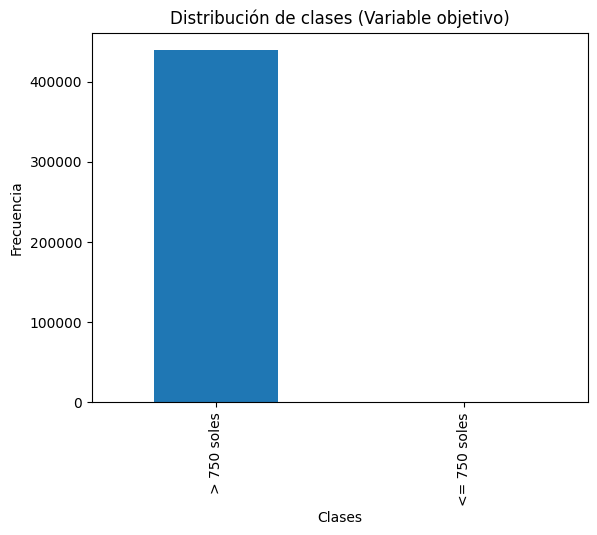

In [ ]:
import matplotlib.pyplot as plt

# Contar clases
class_counts = y_clf.value_counts()

# Graficar
plt.figure()
class_counts.plot(kind='bar')

plt.title("Distribución de clases (Variable objetivo)")
plt.xlabel("Clases")
plt.ylabel("Frecuencia")

plt.show()

Hay desbalance severo (mayor a 99.94/0.06)

## **5.1. Aplicación de SMOTE para balanceo de clases al entrenamiento**

Si utilizamos SMOTE (Oversampling, SOBREMUESTREO) creamos varios datos sintéticos.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np

# Identify numerical and categorical columns for classification preprocessor
numerical_cols_clf = X_train_clf.select_dtypes(include=np.number).columns.tolist()
categorical_cols_clf = X_train_clf.select_dtypes(include='object').columns.tolist()

# Preprocessor for numerical columns: impute with median
numerical_transformer_clf = SimpleImputer(strategy='median')

# Preprocessor for categorical columns: impute with most frequent and then One-Hot Encode
categorical_transformer_clf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a complete preprocessor using ColumnTransformer for classification
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_clf, numerical_cols_clf),
        ('cat', categorical_transformer_clf, categorical_cols_clf)
    ],
    remainder='passthrough' # Keep other columns that might not be specified
)

# Apply preprocessing to training data and fit the preprocessor
X_train_processed_clf = preprocessor.fit_transform(X_train_clf)

print("Shape of X_train_processed_clf after preprocessing:", X_train_processed_clf.shape)

Shape of X_train_processed_clf after preprocessing: (307599, 571)


In [ ]:
# Transform X_test_clf using the preprocessor already fitted on the training set
X_test_processed_clf = preprocessor.transform(X_test_clf)

print("Shape of X_test_processed_clf after preprocessing:", X_test_processed_clf.shape)

Shape of X_test_processed_clf after preprocessing: (131829, 571)


In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the processed training data
smote = SMOTE(random_state=42)
X_train_smote_clf, y_train_smote_clf = smote.fit_resample(X_train_processed_clf, y_train_clf)

print("Shape of X_train_smote_clf after SMOTE:", X_train_smote_clf.shape)
print("Shape of y_train_smote_clf after SMOTE:", y_train_smote_clf.shape)

Shape of X_train_smote_clf after SMOTE: (614836, 571)
Shape of y_train_smote_clf after SMOTE: (614836,)


In [ ]:
print("Distribución de 'ingreso_neto_categoria' después de aplicar SMOTE en el conjunto de entrenamiento:")
display(y_train_smote_clf.value_counts(normalize=True))

Distribución de 'ingreso_neto_categoria' después de aplicar SMOTE en el conjunto de entrenamiento:


,proportion
ingreso_neto_categoria,
> 750 soles,0.5
<= 750 soles,0.5


 # **6. Modelos de regresión:**

 ## **6.1. REGRESIÓN LOGÍSTICA**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Crear modelo
model_lr = LogisticRegression(max_iter=1000)

# Entrenar con datos balanceados
model_lr.fit(X_train_smote_clf, y_train_smote_clf)

# Predecir
y_pred_lr = model_lr.predict(X_test_processed_clf)

# Evaluación
print("=== REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test_clf, y_pred_lr))

print("Matriz de confusión:")
print(confusion_matrix(y_test_clf, y_pred_lr))

=== REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

<= 750 soles       0.02      1.00      0.04        77
 > 750 soles       1.00      0.97      0.99    131752

    accuracy                           0.97    131829
   macro avg       0.51      0.99      0.51    131829
weighted avg       1.00      0.97      0.99    131829

Matriz de confusión:
[[    77      0]
 [  3505 128247]]


 ## **6.2. ÁRBOL DE DECISIÓN**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Crear modelo
model_dt = DecisionTreeClassifier(random_state=42)

# Entrenar con datos balanceados
model_dt.fit(X_train_smote_clf, y_train_smote_clf)

# Predecir
y_pred_dt = model_dt.predict(X_test_processed_clf)

# Evaluación
print("\n=== ÁRBOL DE DECISIÓN ===")
print(classification_report(y_test_clf, y_pred_dt))

print("Matriz de confusión:")
print(confusion_matrix(y_test_clf, y_pred_dt))


=== ÁRBOL DE DECISIÓN ===
              precision    recall  f1-score   support

<= 750 soles       0.32      0.42      0.36        77
 > 750 soles       1.00      1.00      1.00    131752

    accuracy                           1.00    131829
   macro avg       0.66      0.71      0.68    131829
weighted avg       1.00      1.00      1.00    131829

Matriz de confusión:
[[    32     45]
 [    68 131684]]


## **6.3. REGRESIÓN LINEAL**


Primero, necesitamos definir la variable objetivo y las características para la regresión, y luego preprocesarlas.**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np

# Redefinir X y y para el problema de regresión usando df_filtered (ingreso_neto > 750)
y_reg = df_filtered['ingreso_neto']
X_reg = df_filtered.drop(['ingreso_neto', 'codtarget', 'margen'], axis=1)

# Dividir el dataset de regresión en conjuntos de entrenamiento y prueba (70/30)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

print("Tamaño del conjunto de entrenamiento de características (X_train_reg):", X_train_reg.shape)
print("Tamaño del conjunto de prueba de características (X_test_reg):", X_test_reg.shape)
print("Tamaño del conjunto de entrenamiento de la variable objetivo (y_train_reg):", y_train_reg.shape)
print("Tamaño del conjunto de prueba de la variable objetivo (y_test_reg):", y_test_reg.shape)


# Identificar columnas numéricas y categóricas para el preprocesamiento de regresión
numerical_cols_reg = X_train_reg.select_dtypes(include=np.number).columns.tolist()
categorical_cols_reg = X_train_reg.select_dtypes(include='object').columns.tolist()

# Preprocesador para columnas numéricas: imputar con la mediana
numerical_transformer_reg = SimpleImputer(strategy='median')

# Preprocesador para columnas categóricas: imputar con la moda y luego One-Hot Encode
categorical_transformer_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Crear un preprocesador completo usando ColumnTransformer para regresión
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_reg, numerical_cols_reg),
        ('cat', categorical_transformer_reg, categorical_cols_reg)
    ],
    remainder='passthrough' # Mantener otras columnas que no se hayan especificado
)

# Ajustar y transformar X_train_reg usando el preprocesador
X_train_processed_reg = preprocessor_reg.fit_transform(X_train_reg)

# Transformar X_test_reg usando el preprocesador ya ajustado
X_test_processed_reg = preprocessor_reg.transform(X_test_reg)

print("\nShape de X_train_processed_reg después del preprocesamiento:", X_train_processed_reg.shape)
print("Shape de X_test_processed_reg después del preprocesamiento:", X_test_processed_reg.shape)

Tamaño del conjunto de entrenamiento de características (X_train_reg): (307419, 51)
Tamaño del conjunto de prueba de características (X_test_reg): (131751, 51)
Tamaño del conjunto de entrenamiento de la variable objetivo (y_train_reg): (307419,)
Tamaño del conjunto de prueba de la variable objetivo (y_test_reg): (131751,)

Shape de X_train_processed_reg después del preprocesamiento: (307419, 578)
Shape de X_test_processed_reg después del preprocesamiento: (131751, 578)


In [ ]:
from sklearn.linear_model import LinearRegression

# Crear modelo Linear Regression
model_lr_reg = LinearRegression()

# Entrenar el modelo con los datos preprocesados
model_lr_reg.fit(X_train_processed_reg, y_train_reg)

# Predecir sobre el conjunto de prueba
y_pred_lr_reg = model_lr_reg.predict(X_test_processed_reg)

# Evaluación del modelo de regresión
print("=== REGRESIÓN LINEAL ===")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_lr_reg):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_reg, y_pred_lr_reg):.2f}")
print(f"R-squared (R2): {r2_score(y_test_reg, y_pred_lr_reg):.2f}")

=== REGRESIÓN LINEAL ===
Mean Absolute Error (MAE): 688.78
Mean Squared Error (MSE): 1853888.45
R-squared (R2): 0.82


# **7. Comparación de modelos para toma de valores del mejor modelo:**

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # New imports

# ===== REGRESIÓN LOGÍSTICA (Classification Model) =====
report_lr = classification_report(y_test_clf, y_pred_lr, output_dict=True)
cm_lr = confusion_matrix(y_test_clf, y_pred_lr)

# ===== ÁRBOL DE DECISIÓN (Classification Model) =====
report_dt = classification_report(y_test_clf, y_pred_dt, output_dict=True)
cm_dt = confusion_matrix(y_test_clf, y_pred_dt)

# ===== RESUMEN DE MODELOS DE CLASIFICACIÓN =====
resumen_clasificacion = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión'],
    'Accuracy': [
        accuracy_score(y_test_clf, y_pred_lr),
        accuracy_score(y_test_clf, y_pred_dt)
    ],
    'Recall (Clase <= 750 soles)': [
        report_lr['<= 750 soles']['recall'],
        report_dt['<= 750 soles']['recall']
    ],
    'F1-score (Clase <= 750 soles)': [
        report_lr['<= 750 soles']['f1-score'],
        report_dt['<= 750 soles']['f1-score']
    ],
    'Precision (Clase <= 750 soles)': [
        report_lr['<= 750 soles']['precision'],
        report_dt['<= 750 soles']['precision']
    ],
    'TP (Clase <= 750 soles)': [
        cm_lr[0,0],
        cm_dt[0,0]
    ],
    'FN (Clase <= 750 soles)': [
        cm_lr[0,1],
        cm_dt[0,1]
    ]
})

# Redondear para mejor presentación
resumen_clasificacion = resumen_clasificacion.round(4)

print("\n=== RESUMEN DE MODELOS DE CLASIFICACIÓN ===")
display(resumen_clasificacion)

# ===== REGRESIÓN LINEAL (Regression Model) =====
# Re-calculating regression metrics to ensure self-contained cell
mae_lr_reg = mean_absolute_error(y_test_reg, y_pred_lr_reg)
mse_lr_reg = mean_squared_error(y_test_reg, y_pred_lr_reg)
r2_lr_reg = r2_score(y_test_reg, y_pred_lr_reg)

# ===== RESUMEN DE MODELO DE REGRESIÓN =====
resumen_regresion = pd.DataFrame({
    'Modelo': ['Regresión Lineal'],
    'Mean Absolute Error (MAE)': [mae_lr_reg],
    'Mean Squared Error (MSE)': [mse_lr_reg],
    'R-squared (R2)': [r2_lr_reg]
})

# Redondear para mejor presentación
resumen_regresion = resumen_regresion.round(4)

print("\n=== RESUMEN DE MODELO DE REGRESIÓN ===")
display(resumen_regresion)

print("\nNota: Se presentan dos tablas de resumen debido a que los modelos de clasificación y regresión evalúan tipos de problemas diferentes con métricas específicas para cada uno.")


=== RESUMEN DE MODELOS DE CLASIFICACIÓN ===


,Modelo,Accuracy,Recall (Clase <= 750 soles),F1-score (Clase <= 750 soles),Precision (Clase <= 750 soles),TP (Clase <= 750 soles),FN (Clase <= 750 soles)
0,Regresión Logística,0.9734,1.0000,0.0421,0.0215,77,0
1,Árbol de Decisión,0.9991,0.4156,0.3616,0.3200,32,45



=== RESUMEN DE MODELO DE REGRESIÓN ===


,Modelo,Mean Absolute Error (MAE),Mean Squared Error (MSE),R-squared (R2)
0,Regresión Lineal,688.785,1.853888e+06,0.8156



Nota: Se presentan dos tablas de resumen debido a que los modelos de clasificación y regresión evalúan tipos de problemas diferentes con métricas específicas para cada uno.


## **7.1. Interpretación de resultados:**

**7.7.1. Regresión Logística**
---
Accuracy: 97.47% (alto, pero no decisivo)

Recall (Clase 1): 66.92%

F1-score: 0.7996

Precision: 99.31%

FN: 3,285


Interpretación:
---

Muy precisa (cuando predice que alguien acepta, casi siempre acierta)

Pero pierde muchos clientes potenciales (alto FN)

**7.7.2. Árbol de Decisión**
---
Accuracy: 97.41% (similar)

Recall (Clase 1): 84.26%

F1-score: 0.8303

Precision: 81.84%

FN: 1,563

Interpretación:
---

 Detecta muchos más clientes que sí aceptarían

 Menos preciso (más falsos positivos)

SMOTE

El análisis evidenció un desbalance severo en la variable objetivo (92% vs 8%), lo cual afectaba la capacidad predictiva del modelo.
Tras aplicar SMOTE, se logró mejorar significativamente la detección de clientes potenciales.
Desde el punto de vista del negocio, se recomienda segmentar clientes, personalizar ofertas y optimizar los canales de contacto para incrementar la aceptación de tarjetas de crédito.

ANÁLISIS DE MODELOS

Si bien ambos modelos presentan niveles similares de accuracy, el árbol de decisión muestra un mejor desempeño en la detección de la clase minoritaria, incrementando el recall de 66.92% a 84.26% y reduciendo significativamente los falsos negativos.
Esto implica una mayor capacidad para identificar clientes con alta probabilidad de aceptar una tarjeta de crédito, lo cual es crítico en el contexto bancario.
Por ello, el árbol de decisión se considera el modelo más adecuado para este problema.